In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Truck_sales.csv')
df.head()

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [5]:
df.rename(columns={'Month-Year' : 'date', 'Number_Trucks_Sold' : 'sales'}, inplace=True)

In [6]:
df.head()

,date,sales
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [7]:
df.shape

(144, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   sales   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [9]:
df['date'] = pd.to_datetime(df['date'], format="%d-%b")

df['date'] = df['date'].dt.strftime("%d-%b")

In [10]:
df.head()

,date,sales
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [11]:
df.set_index('date', inplace=True)

In [12]:
import matplotlib.pyplot as plt
import plotly.express as px

In [13]:
fig = px.line(data_frame=df, y='sales')
fig.show()

In [14]:
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
results = adfuller(df)
labels = ['ADF Test statistic', 'p-value', 'Lags used', 'No. of observations']

print('Test de stationalité')
for value, label in zip(results,labels):
    print(f"{label} : {value}")

if results[1]>0.5:
    print("l'Hypothèse nulle H0 est rejetée, la série n'est pas stationaire")
else:
    print("l'Hypothèse nulle H0 est acceptée, la série est stationaire")


Test de stationalité
ADF Test statistic : 1.1158932574252591
p-value : 0.9953500083802601
Lags used : 14
No. of observations : 129
l'Hypothèse nulle H0 est rejetée, la série n'est pas stationaire


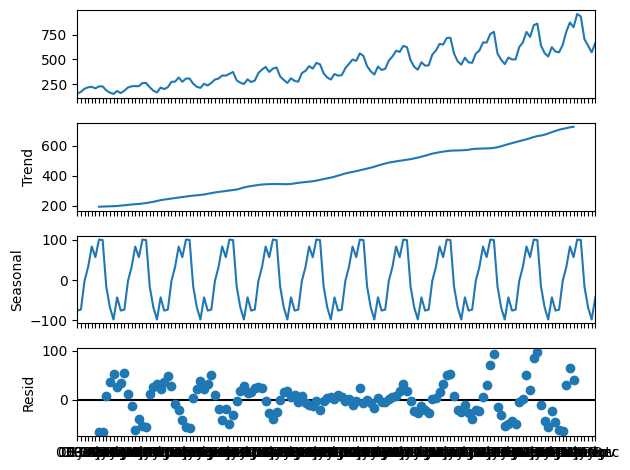

In [16]:
decomp = seasonal_decompose(df, period=12)
decomp.plot()
plt.show()

<Axes: xlabel='date'>

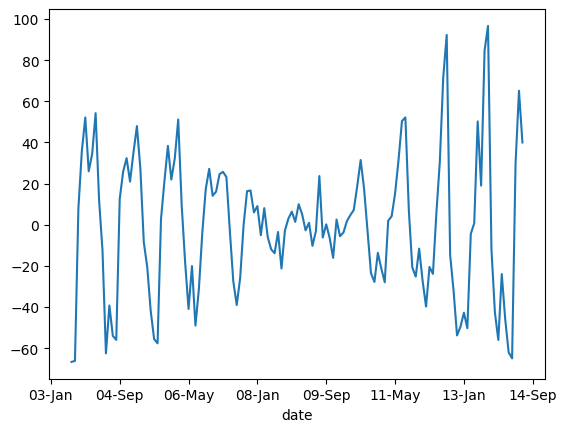

In [17]:
decomp.resid.plot()

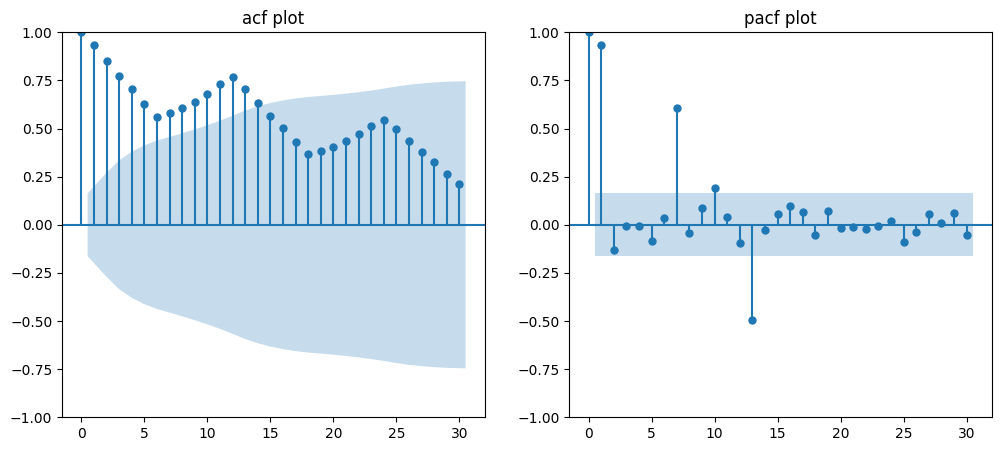

In [18]:
figure, ax = plt.subplots(1, 2, figsize=(12,5))
plot_acf(df, lags=30, ax=ax[0])
ax[0].set_title('acf plot')

plot_pacf(df, lags=30, ax=ax[1])
ax[1].set_title('pacf plot')

plt.show()

In [19]:
mod = arma_order_select_ic(df)

In [20]:
mod.bic_min_order

(3, 2)

In [21]:
import pmdarima as pmd

In [22]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [23]:
model = pmd.auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True,
                       seasonal=True, m=12, stepwise=True,
                       start_P=0, max_P=12, start_q=0, max_q=12, start_d=0, max_d=2)

Performing stepwise search to minimize aic
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=1026.514, Time=0.47 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1132.711, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1026.241, Time=0.40 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1077.231, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1296.808, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1026.350, Time=0.09 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1026.491, Time=1.10 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=1026.686, Time=0.53 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.35 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1132.185, Time=0.36 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=1026.084, Time=0.53 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=1025.722, Time=0.14 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.75 sec
 ARIMA(3,0,0)(0,1,0)[12] intercept

In [24]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -508.861
Date:                            Thu, 14 Nov 2024   AIC                           1025.722
Time:                                    23:44:01   BIC                           1036.872
Sample:                                         0   HQIC                          1030.250
                                            - 132                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      8.1760      3.282      2.491      0.013       1.743      14.609
ar.L1          0.6741      0.091      7.415      0.000       0.496       0.852
ar.L2          0.1509      0.092      1.640      0.101      -0.029       0.331
sigma2       279.7760     34.616      8.082      0.000     211.929     347.623
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.68
Prob(Q):                              0.92   Prob(JB):                         0.71
Heteroskedasticity (H):               1.36   Skew:                            -0.05
Prob(H) (two-sided):                  0.33   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
resid = model.resid()
px.line(resid)

In [26]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

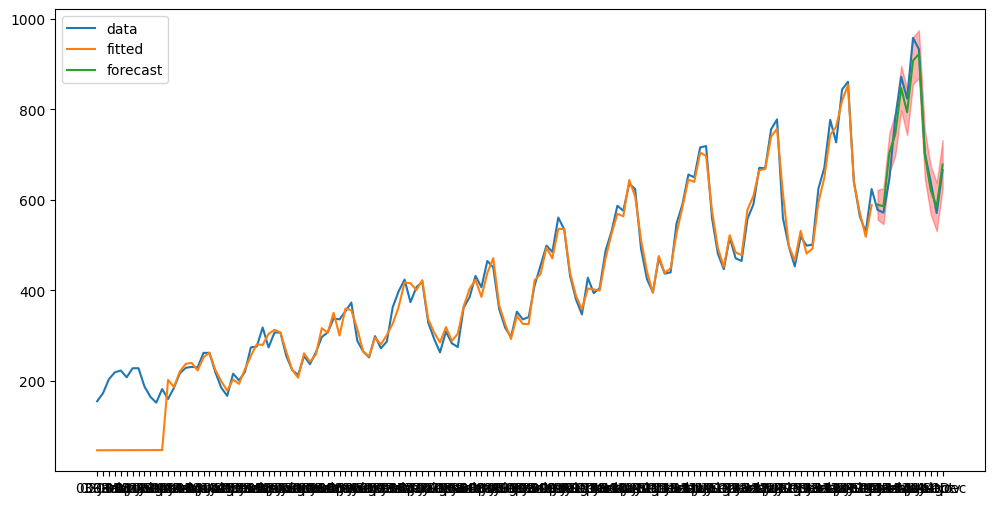

In [27]:
# Ajuster le début des prédictions pour tenir compte de d=2
train_pred = model.predict_in_sample(start=0, end=len(train.index) - 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['sales'], label='data')
ax.plot(train.index, train_pred, label='fitted')  # Ajustez l'index pour qu'il corresponde aux prédictions
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, confint[:, 0], confint[:, 1], color='red', alpha=0.3)
ax.legend()
plt.show()

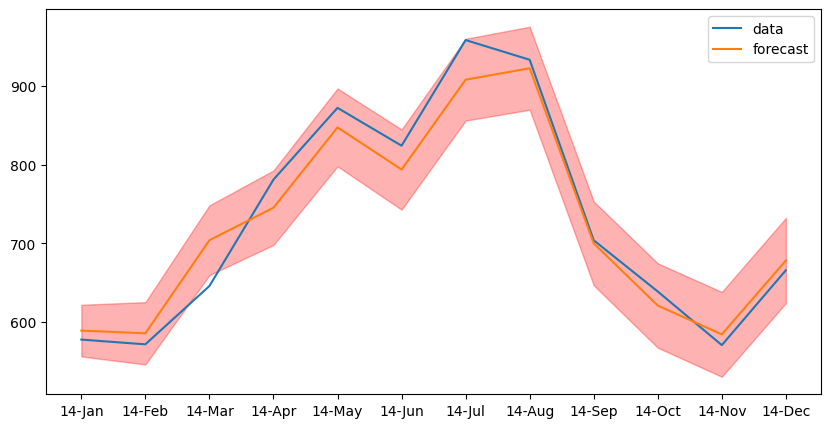

In [28]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(test.index, test['sales'], label='data')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

In [29]:
from scipy.stats import jarque_bera

# Test de Jarque-Bera
jb_test_stat, jb_p_value = jarque_bera(model.resid())
print(f"Test de Jarque-Bera : Statistique = {jb_test_stat}, p-value = {jb_p_value}")

Test de Jarque-Bera : Statistique = 270.517459836039, p-value = 1.8108395339068285e-59


In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(df, order=(2, 0, 3), seasonal_order=(0, 1, 0, 12))
model_fit = model.fit(disp=False)


In [51]:
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                  144
Model:             SARIMAX(2, 0, 3)x(0, 1, [], 12)   Log Likelihood                -573.441
Date:                             Fri, 15 Nov 2024   AIC                           1158.882
Time:                                     00:25:09   BIC                           1176.179
Sample:                                          0   HQIC                          1165.911
                                             - 144                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7648      0.145     12.169      0.000       1.481       2.049
ar.L2         -0.7650      

In [37]:
# Faire une prédiction sur les 12 prochaines périodes
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean  # Prédictions
forecast_ci = forecast.conf_int()        # Intervalles de confiance

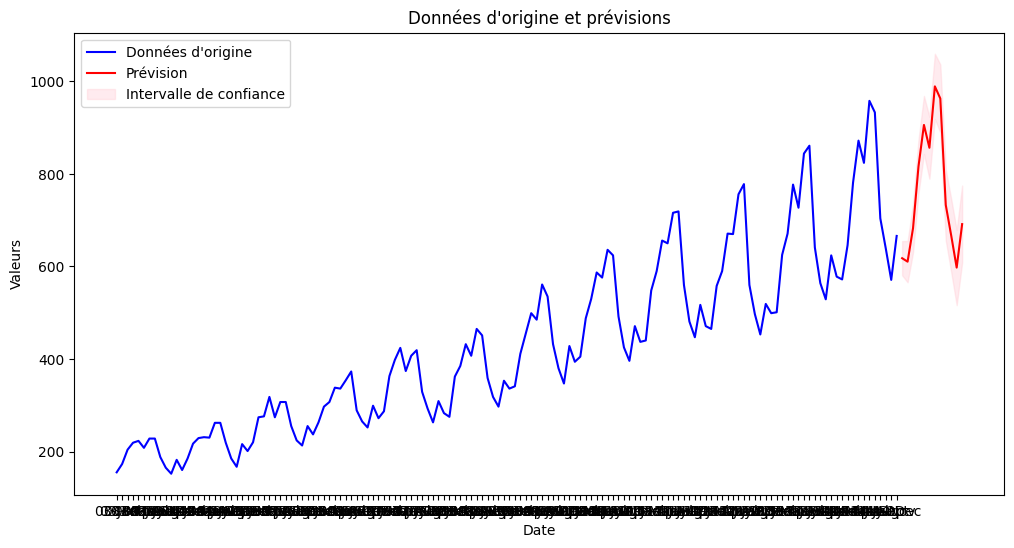

In [38]:
# Tracer les données d'origine
plt.figure(figsize=(12, 6))
plt.plot(df.index, df, label='Données d\'origine', color='blue')

# Tracer les prévisions
plt.plot(forecast_mean.index, forecast_mean, label='Prévision', color='red')

# Ajouter les intervalles de confiance
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalle de confiance')

# Ajouter des légendes et afficher
plt.xlabel('Date')
plt.ylabel('Valeurs')
plt.legend()
plt.title("Données d'origine et prévisions")
plt.show()